In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm

pd.set_option("display.max_columns", None)


In [ ]:
file_path = "/content/reviews.csv"

chunk_size = 250_000  # adjust based on RAM

total_rows = 0
missing_counts = Counter()
dtype_counts = Counter()
unique_counts = {}

# Numeric aggregations
numeric_sums = Counter()
numeric_squared_sums = Counter()
numeric_counts = Counter()
numeric_mins = {}
numeric_maxs = {}


In [ ]:
for chunk in tqdm(pd.read_csv(
    file_path,
    chunksize=chunk_size,
    engine="c",
    on_bad_lines="skip",
    skip_blank_lines=True
)):
    total_rows += len(chunk)

    # Standardize
    chunk.columns = chunk.columns.str.lower()

    # --- Missing value analysis ---
    for col in chunk.columns:
        missing_counts[col] += chunk[col].isna().sum()

    # --- Dtype counts ---
    for col in chunk.columns:
        dtype_counts[str(chunk[col].dtype)] += 1

    # --- Unique count approximation (HyperLogLog alternative) ---
    for col in chunk.columns:
        if col not in unique_counts:
            unique_counts[col] = set()
        unique_counts[col].update(chunk[col].dropna().sample(
            min(5000, chunk[col].dropna().shape[0])
        ))

    # --- Numeric aggregations ---
    numeric_cols = chunk.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        numeric_sums[col] += chunk[col].sum(skipna=True)
        numeric_squared_sums[col] += (chunk[col] ** 2).sum(skipna=True)
        numeric_counts[col] += chunk[col].count()

        # mins & max
        if col not in numeric_mins:
            numeric_mins[col] = chunk[col].min(skipna=True)
            numeric_maxs[col] = chunk[col].max(skipna=True)
        else:
            numeric_mins[col] = min(numeric_mins[col], chunk[col].min(skipna=True))
            numeric_maxs[col] = max(numeric_maxs[col], chunk[col].max(skipna=True))


1it [00:05,  5.14s/it]


In [ ]:
missing_df = pd.DataFrame.from_dict(missing_counts, orient="index", columns=["missing"])
missing_df["missing_%"] = (missing_df["missing"] / total_rows) * 100
missing_df.sort_values("missing_%", ascending=False)


,missing,missing_%
author_playtime_at_review,58977,25.48
review_text,110,0.05
updated_at,1,0.00
author_num_games_owned,0,0.00
recommendationid,0,0.00
appid,0,0.00
author_steamid,0,0.00
author_playtime_last_two_weeks,0,0.00
author_playtime_forever,0,0.00
author_num_reviews,0,0.00


In [ ]:
unique_count_df = pd.DataFrame({
    "column": list(unique_counts.keys()),
    "approx_unique_values": [len(v) for v in unique_counts.values()]
}).sort_values("approx_unique_values")
unique_count_df


,column,approx_unique_values
2,author_steamid,1
18,steam_purchase,1
21,created_at,1
13,voted_up,2
19,received_for_free,2
20,written_during_early_access,2
6,author_playtime_last_two_weeks,14
17,comment_count,19
22,updated_at,24
9,language,27


In [ ]:
summary = []

for col in numeric_counts:
    mean = numeric_sums[col] / numeric_counts[col]
    variance = (numeric_squared_sums[col] / numeric_counts[col]) - mean**2
    std = np.sqrt(max(variance, 0))

    summary.append({
        "column": col,
        "count": numeric_counts[col],
        "mean": mean,
        "std": std,
        "min": numeric_mins[col],
        "max": numeric_maxs[col],
    })

numeric_summary_df = pd.DataFrame(summary)
numeric_summary_df


,column,count,mean,std,min,max
0,recommendationid,231493,123149638.54,0.00,10862.00,171403321.00
1,appid,231493,1539929.10,758167.32,2680.00,3125520.00
2,author_steamid,231493,76561200000000000.00,0.00,76561200000000000.00,76561200000000000.00
3,author_num_games_owned,231493,505.96,1489.01,0.00,33484.00
4,author_num_reviews,231493,287.30,1252.79,1.00,18323.00
5,author_playtime_forever,231493,836.40,13337.71,0.00,1668966.00
6,author_playtime_last_two_weeks,231493,2.55,161.14,0.00,20112.00
7,author_playtime_at_review,172516,504.41,6770.60,1.00,888515.00
8,author_last_played,231493,1239825107.50,0.00,0.00,1757046421.00
9,timestamp_created,231493,1654362765.07,0.00,1290188912.00,1722753224.00


In [ ]:
dtype_counts


Counter({'int64': 12, 'float64': 3, 'object': 4, 'bool': 4})

In [ ]:
sample = pd.read_csv(file_path, on_bad_lines="skip", engine="python")

# Convert timestamps
sample["timestamp_created"] = pd.to_datetime(sample["timestamp_created"], unit="s", errors="coerce")

# Review Length
sample["review_length"] = sample["review_text"].fillna("").str.len()

# Playtime Log
sample["playtime_norm"] = np.log1p(sample["author_playtime_forever"].fillna(0))

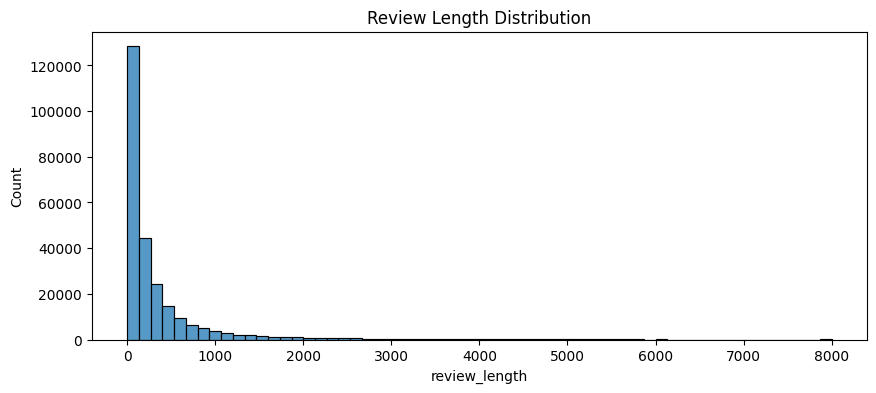

In [ ]:
plt.figure(figsize=(10,4))
sns.histplot(sample["review_length"], bins=60)
plt.title("Review Length Distribution")
plt.show()


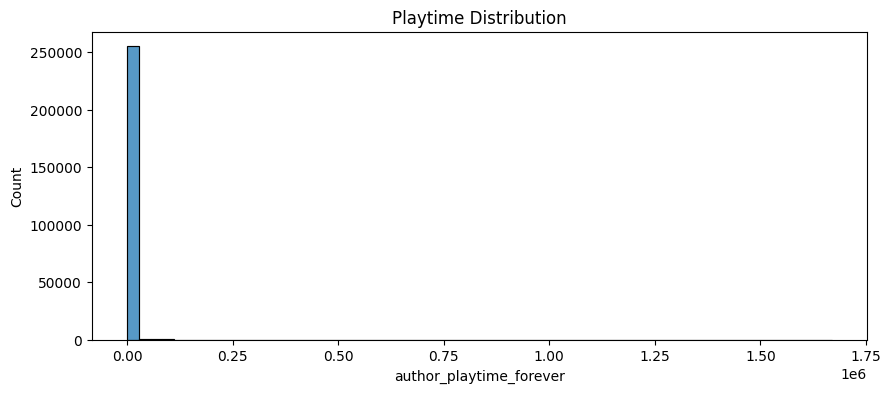

In [ ]:
plt.figure(figsize=(10,4))
sns.histplot(sample["author_playtime_forever"], bins=60)
plt.title("Playtime Distribution")
plt.show()


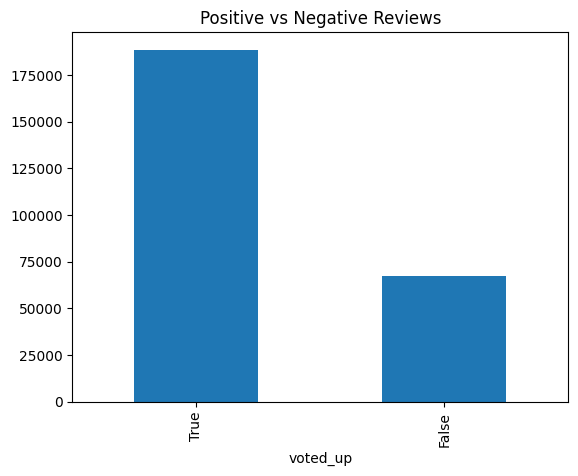

In [ ]:
sample["voted_up"].value_counts().plot(kind="bar")
plt.title("Positive vs Negative Reviews")
plt.show()


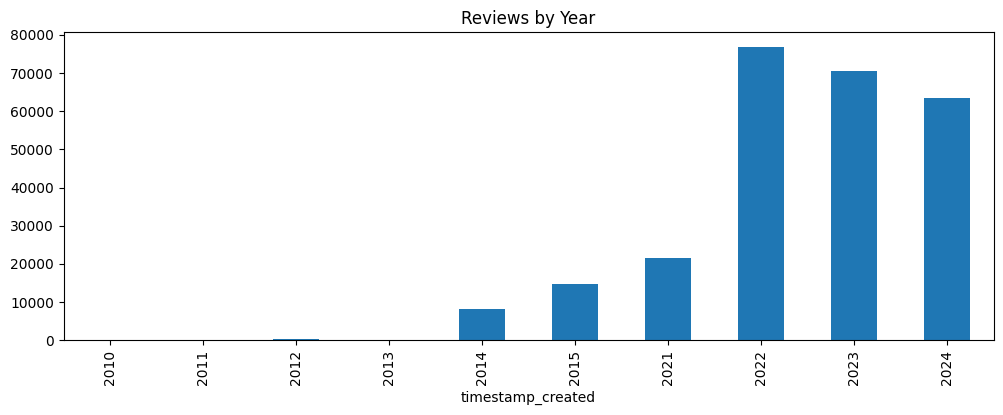

In [ ]:
sample["timestamp_created"].dt.year.value_counts().sort_index().plot(kind="bar", figsize=(12,4))
plt.title("Reviews by Year")
plt.show()


In [ ]:
# ============================================================
# EDA FOR reviews.csv  (Steam User Reviews)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

# ------------------------------------------------------------
# 1. LOAD DATA (USE SAMPLING TO HANDLE HUGE FILE)
# ------------------------------------------------------------

# OPTIONAL: load 1–2 million rows for fast EDA
reviews = pd.read_csv(
    "/content/reviews.csv",
    engine="python",
    on_bad_lines="skip",
    skip_blank_lines=True
)

reviews_raw = reviews.copy()

print("Shape:", reviews.shape)
reviews.head()

Shape: (54104, 23)


,recommendationid,appid,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,language,review_text,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,created_at,updated_at
0,10000000,264220,76561200000000000.00,760,74,12,0,12.00,1399059573,polish,What's a crap. This game costs 2 euro but is w...,1399059965,1399059965,True,0,1,0.46,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
1,100001066,1006440,76561200000000000.00,485,234,424,0,424.00,1632666417,russian,"Игра в жанре квеста point-&-click, но особенно...",1632673992,1632673992,True,8,0,0.63,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
2,100002344,320721,76561200000000000.00,0,385,0,0,NaN,0,german,Erneut gibt es einen DLC mit drei neuen Lords ...,1632675631,1632675631,False,1,0,0.52,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
3,100002361,1604700,76561200000000000.00,0,3,86,0,86.00,1632674318,english,"It took me a grueling 18 months, but I built a...",1632675648,1632680067,True,3,0,0.54,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
4,100002504,1338560,76561200000000000.00,816,26,25,0,25.00,1632639242,english,incredibly simple game. it does get boring qui...,1632675819,1632675819,True,1,0,0.52,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00


In [ ]:
reviews.columns = reviews.columns.str.lower()
reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54104 entries, 0 to 54103
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   recommendationid                54104 non-null  int64  
 1   appid                           54104 non-null  int64  
 2   author_steamid                  54104 non-null  float64
 3   author_num_games_owned          54104 non-null  int64  
 4   author_num_reviews              54104 non-null  int64  
 5   author_playtime_forever         54104 non-null  int64  
 6   author_playtime_last_two_weeks  54104 non-null  int64  
 7   author_playtime_at_review       40362 non-null  float64
 8   author_last_played              54104 non-null  int64  
 9   language                        54104 non-null  object 
 10  review_text                     54068 non-null  object 
 11  timestamp_created               54104 non-null  int64  
 12  timestamp_updated               

In [ ]:
missing = reviews.isna().sum().sort_values(ascending=False)
missing


,0
author_playtime_at_review,13742
review_text,36
steam_purchase,1
updated_at,1
created_at,1
written_during_early_access,1
received_for_free,1
author_playtime_last_two_weeks,0
author_playtime_forever,0
author_num_reviews,0


In [ ]:
reviews.describe()


,recommendationid,appid,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,timestamp_created,timestamp_updated,votes_up,votes_funny,weighted_vote_score,comment_count
count,54104.00,54104.00,54104.00,54104.00,54104.00,54104.00,54104.00,40362.00,54104.00,54104.00,54104.00,54104.00,54104.00,54104.00,54104.00
mean,103523038.81,1314369.29,76561200000000000.00,430.09,177.22,989.76,1.84,560.24,1222314055.85,1631263124.98,1633093089.34,4.85,0.81,0.52,0.15
std,21312808.84,523340.64,104672.97,1300.05,587.66,15210.62,108.14,8029.48,716027191.67,51876901.47,52228283.65,27.14,11.34,0.07,1.62
min,10862.00,2690.00,76561200000000000.00,0.00,1.00,0.00,0.00,1.00,0.00,1290460905.00,1290460905.00,0.00,0.00,0.01,0.00
25%,103081534.00,956947.00,76561200000000000.00,0.00,5.00,0.00,0.00,27.00,0.00,1637353504.75,1637585146.00,0.00,0.00,0.50,0.00
50%,107913206.00,1490114.00,76561200000000000.00,3.00,21.00,55.00,0.00,80.00,1639669280.00,1642070934.50,1642392074.00,1.00,0.00,0.50,0.00
75%,112165084.50,1753900.00,76561200000000000.00,308.00,93.00,239.00,0.00,233.00,1649474263.75,1647253514.00,1647864017.75,4.00,0.00,0.54,0.00
max,115951752.00,2004790.00,76561200000000000.00,24652.00,11133.00,1120041.00,20089.00,870567.00,1756900489.00,1653413806.00,1756535693.00,2789.00,1609.00,0.99,279.00


In [ ]:
reviews.describe(include="object").transpose()


,count,unique,top,freq
language,54104,28,english,29924
review_text,54068,52174,good,71
steam_purchase,54103,1,True,54103
received_for_free,54103,2,False,53599
written_during_early_access,54103,2,False,48277
created_at,54103,1,2025-09-07 12:51:00.564782+00:00,54103
updated_at,54103,6,2025-09-08 00:47:55.754043+00:00,10000


In [ ]:
reviews.nunique().sort_values()


,0
author_steamid,1
steam_purchase,1
created_at,1
voted_up,2
received_for_free,2
written_during_early_access,2
updated_at,6
language,28
comment_count,37
author_playtime_last_two_weeks,114


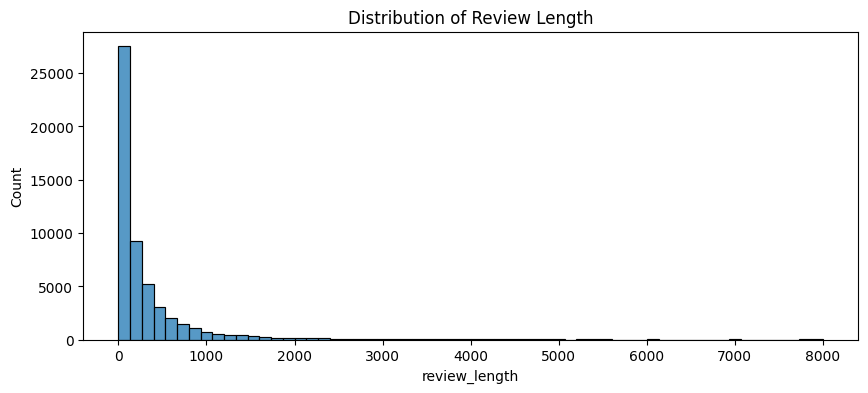

,review_length
count,54104.00
mean,338.96
std,642.72
min,0.00
25%,41.00
50%,129.00
75%,355.00
max,8000.00


In [ ]:
reviews["review_length"] = reviews["review_text"].fillna("").str.len()

plt.figure(figsize=(10,4))
sns.histplot(reviews["review_length"], bins=60)
plt.title("Distribution of Review Length")
plt.show()

reviews["review_length"].describe()


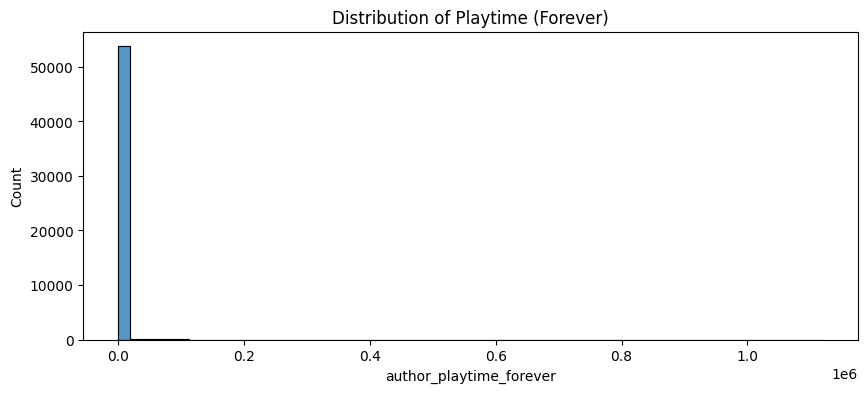

,author_playtime_forever
count,54104.00
mean,989.76
std,15210.62
min,0.00
25%,0.00
50%,55.00
75%,239.00
max,1120041.00


In [ ]:
plt.figure(figsize=(10,4))
sns.histplot(reviews["author_playtime_forever"], bins=60)
plt.title("Distribution of Playtime (Forever)")
plt.show()

reviews["author_playtime_forever"].describe()


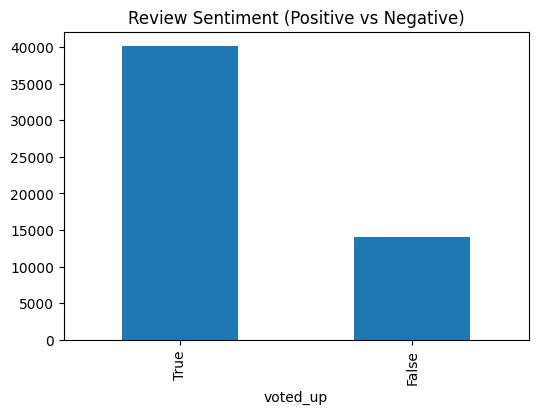

In [ ]:
plt.figure(figsize=(6,4))
reviews["voted_up"].value_counts().plot(kind="bar")
plt.title("Review Sentiment (Positive vs Negative)")
plt.show()


In [ ]:
reviews["timestamp_created"] = pd.to_datetime(reviews["timestamp_created"], unit="s", errors="coerce")
reviews["timestamp_updated"] = pd.to_datetime(reviews["timestamp_updated"], unit="s", errors="coerce")


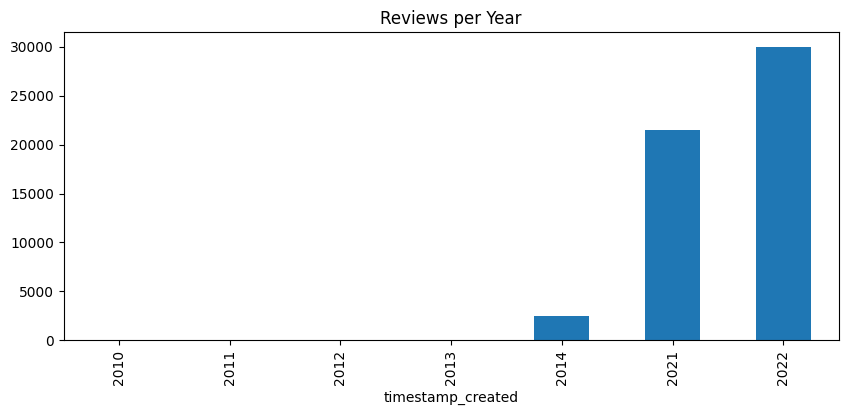

In [ ]:
reviews["timestamp_created"].dt.year.value_counts().sort_index().plot(kind="bar", figsize=(10,4))
plt.title("Reviews per Year")
plt.show()


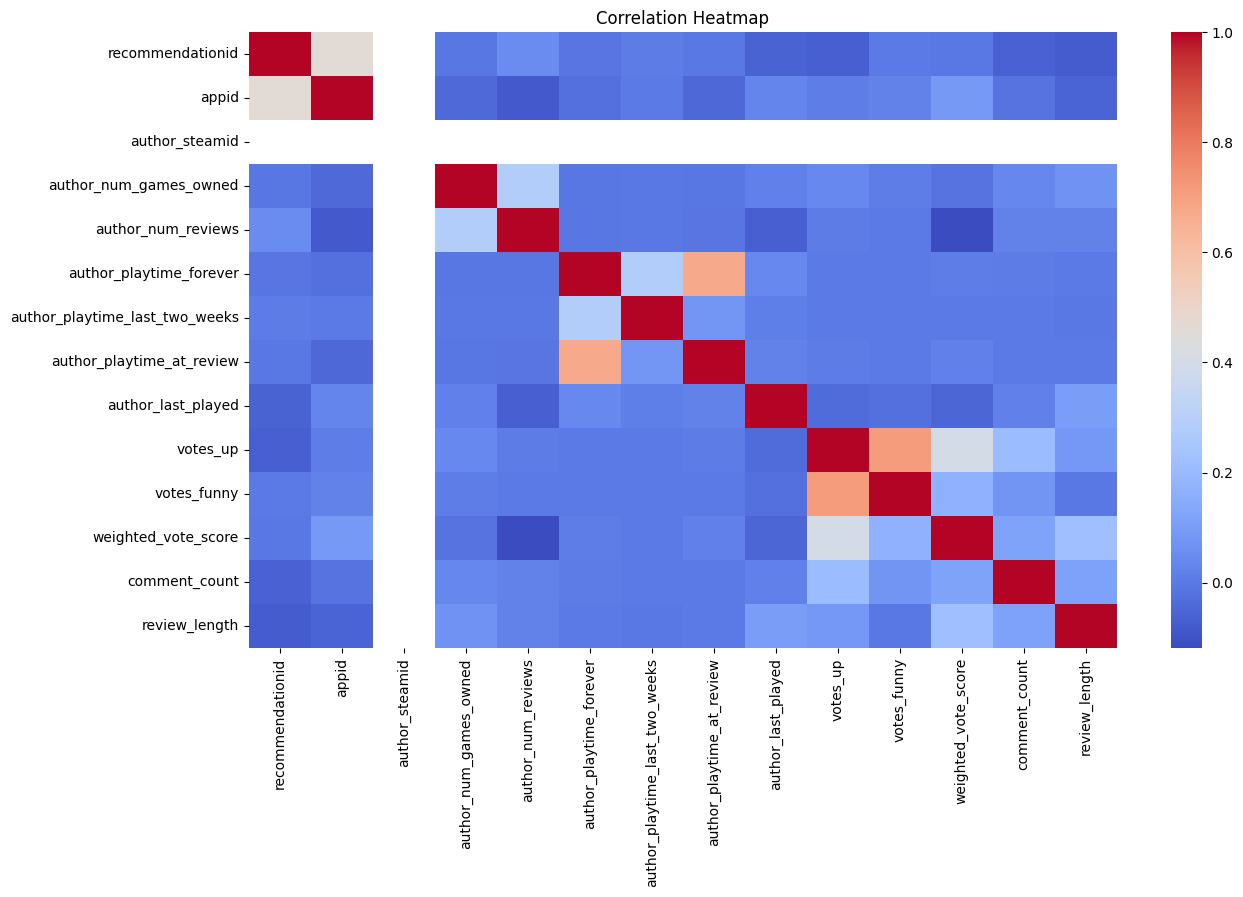

In [ ]:
plt.figure(figsize=(14,8))
sns.heatmap(reviews.select_dtypes(include=np.number).corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
drop_cols = []

# Rule 1 — >70% missing
for col in reviews.columns:
    if reviews[col].isna().mean() > 0.70:
        drop_cols.append(col)

# Rule 2 — low variance (mostly 0 or mostly 1)
for col in reviews.columns:
    if reviews[col].nunique() == 1:
        drop_cols.append(col)

# Rule 3 — metadata not needed
drop_cols.extend([
    "timestamp_updated",
    "author_last_played",
    "weighted_vote_score",
    "comment_count"
])

# Rule 4 — optional heavy text columns (drop if not doing NLP)
# drop_cols.append("review_text")

set(drop_cols)


{'author_last_played',
 'author_steamid',
 'comment_count',
 'created_at',
 'steam_purchase',
 'timestamp_updated',
 'weighted_vote_score'}

In [ ]:
reviews_cleaned = reviews.drop(columns=list(set(drop_cols)), errors="ignore")
reviews_cleaned.to_csv("reviews_cleaned_sample.csv", index=False)

print("Cleaned sample saved.")
reviews_cleaned.head()


Cleaned sample saved.


,recommendationid,appid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,language,review_text,timestamp_created,voted_up,votes_up,votes_funny,received_for_free,written_during_early_access,updated_at,review_length
0,10000000,264220,760,74,12,0,12.00,polish,What's a crap. This game costs 2 euro but is w...,2014-05-02 19:46:05,True,0,1,False,False,2025-09-08 00:47:55.754043+00:00,228
1,100001066,1006440,485,234,424,0,424.00,russian,"Игра в жанре квеста point-&-click, но особенно...",2021-09-26 16:33:12,True,8,0,False,False,2025-09-08 00:47:55.754043+00:00,405
2,100002344,320721,0,385,0,0,NaN,german,Erneut gibt es einen DLC mit drei neuen Lords ...,2021-09-26 17:00:31,False,1,0,False,False,2025-09-08 00:47:55.754043+00:00,162
3,100002361,1604700,0,3,86,0,86.00,english,"It took me a grueling 18 months, but I built a...",2021-09-26 17:00:48,True,3,0,False,False,2025-09-08 00:47:55.754043+00:00,204
4,100002504,1338560,816,26,25,0,25.00,english,incredibly simple game. it does get boring qui...,2021-09-26 17:03:39,True,1,0,False,False,2025-09-08 00:47:55.754043+00:00,281
